In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df=pd.read_csv('/content/ai4i2020.csv')

In [8]:
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [10]:
df.isnull().sum()

,0
UDI,0
Product ID,0
Type,0
Air temperature [K],0
Process temperature [K],0
Rotational speed [rpm],0
Torque [Nm],0
Tool wear [min],0
Machine failure,0
TWF,0


In [11]:
for column in df.columns:
    print(column, ":", df[column].nunique())

UDI : 10000
Product ID : 10000
Type : 3
Air temperature [K] : 93
Process temperature [K] : 82
Rotational speed [rpm] : 941
Torque [Nm] : 577
Tool wear [min] : 246
Machine failure : 2
TWF : 2
HDF : 2
PWF : 2
OSF : 2
RNF : 2


In [12]:
print(df["Machine failure"].value_counts(normalize=True) * 100)

Machine failure
0    96.61
1     3.39
Name: proportion, dtype: float64


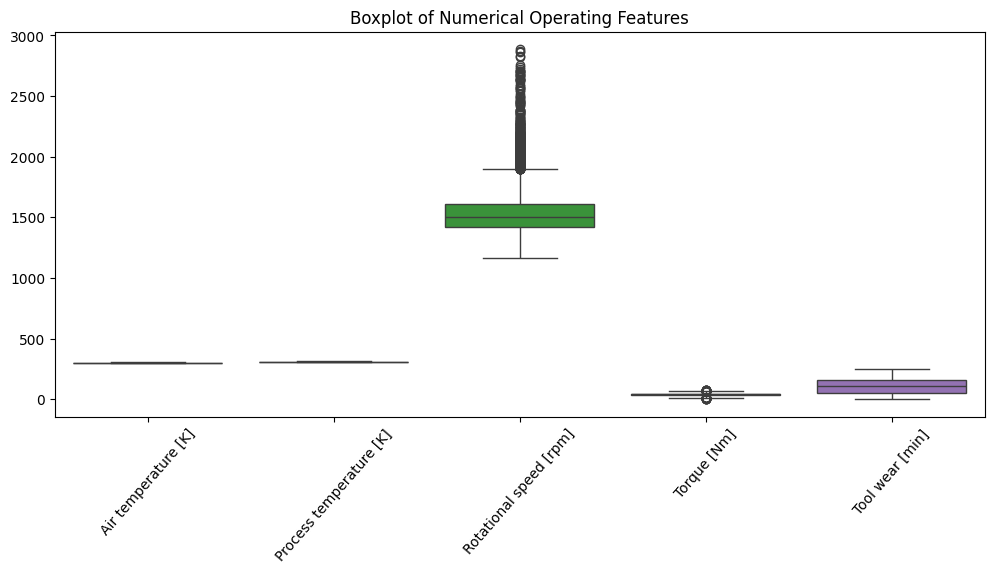

In [14]:
plt.figure(figsize=(12, 5))

sns.boxplot(
    data=df[
        [
            "Air temperature [K]",
            "Process temperature [K]",
            "Rotational speed [rpm]",
            "Torque [Nm]",
            "Tool wear [min]"
        ]
    ]
)

plt.xticks(rotation=49)
plt.title("Boxplot of Numerical Operating Features")
plt.show()


In [15]:
rotational_speed_stats = df.groupby("Machine failure")["Rotational speed [rpm]"].agg(
    ["count", "mean", "median", "min", "max"]
)

rotational_speed_stats

,count,mean,median,min,max
Machine failure,,,,,
0,9661,1540.260014,1507.0,1168,2695
1,339,1496.486726,1365.0,1181,2886


In [16]:
torque_stats = df.groupby("Machine failure")["Torque [Nm]"].agg(
    ["count", "mean", "median", "min", "max"]
)

torque_stats

,count,mean,median,min,max
Machine failure,,,,,
0,9661,39.629655,39.9,12.6,70.0
1,339,50.168142,53.7,3.8,76.6


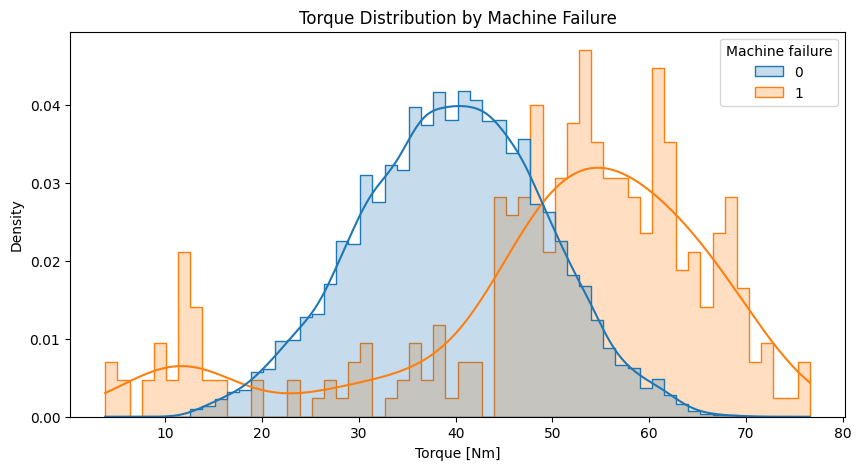

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(
    data=df,
    x="Torque [Nm]",
    hue="Machine failure",
    kde=True,
    element="step",
    stat="density",
    common_norm=False)
plt.title("Torque Distribution by Machine Failure")
plt.xlabel("Torque [Nm]")
plt.ylabel("Density")
plt.show()

In [18]:
mean_torque = df.groupby("Machine failure")["Torque [Nm]"].mean()

print("Mean Torque - No Failure:", mean_torque[0])
print("Mean Torque - Failure:", mean_torque[1])

difference = mean_torque[1] - mean_torque[0]

print("Difference in Mean Torque:", difference)

Mean Torque - No Failure: 39.62965531518476
Mean Torque - Failure: 50.16814159292036
Difference in Mean Torque: 10.538486277735593


In [19]:
tool_wear_stats = df.groupby("Machine failure")["Tool wear [min]"].agg(
    ["count", "mean", "median", "min", "max"]
)

tool_wear_stats

,count,mean,median,min,max
Machine failure,,,,,
0,9661,106.693717,107.0,0,246
1,339,143.781711,165.0,0,253


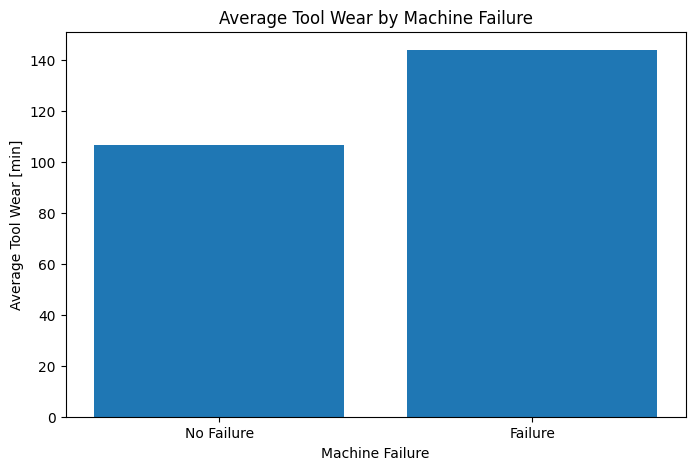

In [20]:
tool_wear_mean = df.groupby("Machine failure")["Tool wear [min]"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    ["No Failure", "Failure"],
    [tool_wear_mean[0], tool_wear_mean[1]]
)

plt.title("Average Tool Wear by Machine Failure")
plt.xlabel("Machine Failure")
plt.ylabel("Average Tool Wear [min]")

plt.show()

In [21]:
numeric_data = df.select_dtypes(include=np.number)

correlation_with_failure = (
    numeric_data.corr()["Machine failure"]
    .sort_values(ascending=False)
)

correlation_with_failure


,Machine failure
Machine failure,1.000000
HDF,0.575800
OSF,0.531083
PWF,0.522812
TWF,0.362904
Torque [Nm],0.191321
Tool wear [min],0.105448
Air temperature [K],0.082556
Process temperature [K],0.035946
RNF,0.004516


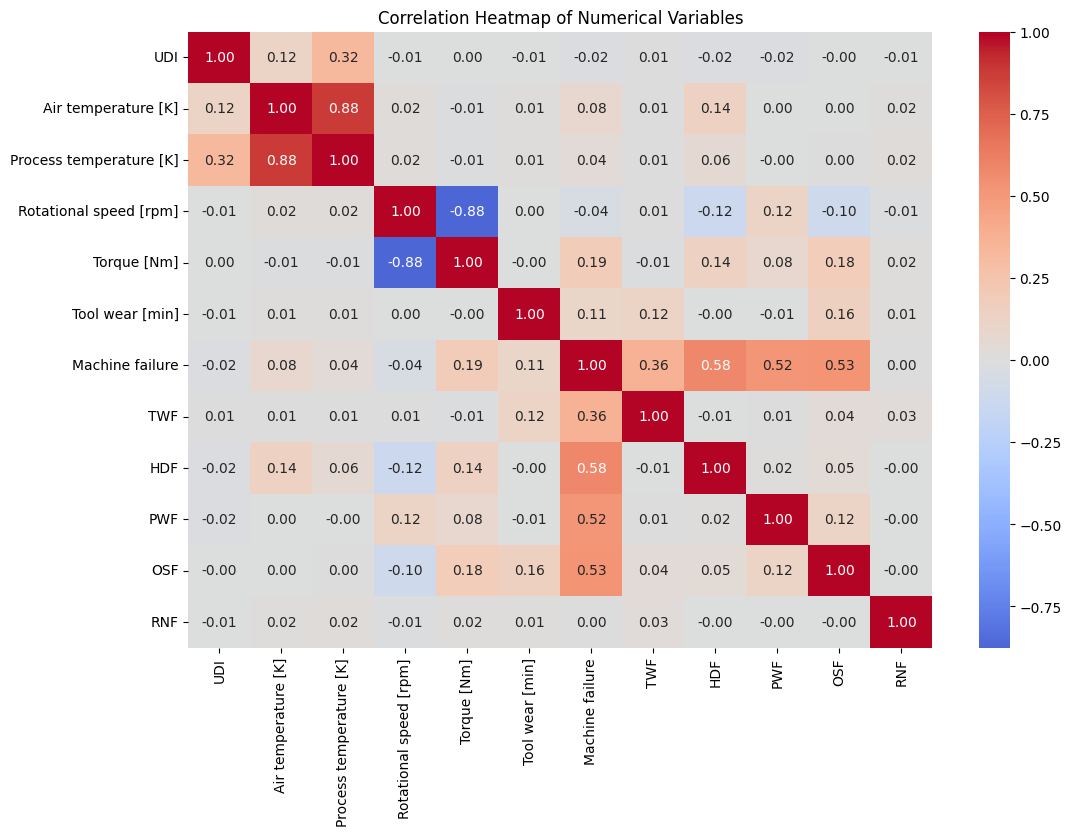

In [22]:
plt.figure(figsize=(12, 8))
correlation_matrix = numeric_data.corr()
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0)
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()

In [24]:
model_df = df.drop(
    columns=[
        "UDI",
        "Product ID",
        "TWF",
        "HDF",
        "PWF",
        "OSF",
        "RNF"
    ]
)

model_df.head()


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [25]:
print("Columns used for modeling:")
print(model_df.columns.tolist())

print("\nShape of modeling dataset:")
print(model_df.shape)

Columns used for modeling:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure']

Shape of modeling dataset:
(10000, 7)


In [26]:
X = model_df.drop("Machine failure", axis=1)
y = model_df["Machine failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

X shape: (10000, 6)
y shape: (10000,)

Target distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


In [27]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training samples: 8000
Testing samples: 2000

Training target distribution:
Machine failure
0    7729
1     271
Name: count, dtype: int64

Testing target distribution:
Machine failure
0    1932
1      68
Name: count, dtype: int64


In [28]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = X.select_dtypes(include="object").columns.tolist()
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['Type']

Numerical features:
['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']


In [29]:
preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numerical", "passthrough", numerical_features)
    ]
)

In [30]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

print(model)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)


In [31]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ]
)

print("Pipeline created successfully.")

Pipeline created successfully.


In [32]:
pipeline.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [33]:
y_pred = pipeline.predict(X_test)

In [34]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Model Evaluation Results")
print("------------------------")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Model Evaluation Results
------------------------
Accuracy : 0.98
Precision: 0.9375
Recall   : 0.4411764705882353
F1 Score : 0.6


In [40]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score

y_proba = pipeline.predict_proba(X_test)[:, 1]

print("ROC-AUC:", roc_auc_score(y_test, y_proba))
print("PR-AUC :", average_precision_score(y_test, y_proba))

prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * prec * rec / (prec + rec + 1e-9)
best = f1_scores.argmax()
print("Best threshold:", thr[best], "| Precision:", prec[best], "| Recall:", rec[best])

ROC-AUC: 0.9586530264279626
PR-AUC : 0.7710820423800884
Best threshold: 0.245 | Precision: 0.6973684210526315 | Recall: 0.7794117647058824


In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300, max_depth=5, learning_rate=0.1,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    eval_metric="aucpr", random_state=42
)

In [44]:

import pandas as pd
import numpy as np

ts = df.sort_values("UDI").reset_index(drop=True).copy()

SENSORS = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Tool wear [min]",
]

WINDOW = 20

for col in SENSORS:
    # .shift(1) is CRITICAL - it makes the window use only PAST rows.
    # Without it the current reading leaks into its own feature and
    # your scores become fake.
    past = ts[col].shift(1)

    ts[f"{col}_roll_mean"] = past.rolling(WINDOW, min_periods=5).mean()
    ts[f"{col}_roll_std"]  = past.rolling(WINDOW, min_periods=5).std()
    ts[f"{col}_delta"]     = ts[col] - past
    ts[f"{col}_zscore"]    = (
        (ts[col] - ts[f"{col}_roll_mean"]) / (ts[f"{col}_roll_std"] + 1e-6)
    )

# Two engineered physics features - these usually rank high in importance
ts["Power [W]"] = ts["Torque [Nm]"] * ts["Rotational speed [rpm]"] * (2 * np.pi / 60)
ts["Temp difference [K]"] = ts["Process temperature [K]"] - ts["Air temperature [K]"]

ts = ts.dropna().reset_index(drop=True)
print("Shape after rolling features:", ts.shape)
print("New feature count:", len(ts.columns) - len(df.columns))


# ---------------------------------------------------------------------
# PHASE B — RETRAIN ON A TIME-ORDERED SPLIT
#
# Your old train_test_split(shuffle=True) is now INVALID. Rolling
# features carry information across rows, so a random split lets the
# test set peek at the training set. Split by position instead.
# ---------------------------------------------------------------------

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    roc_auc_score, classification_report, confusion_matrix,
)

DROP = ["UDI", "Product ID", "Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]

X = ts.drop(columns=DROP)
y = ts["Machine failure"]

split_at = int(len(ts) * 0.80)
X_train, X_test = X.iloc[:split_at], X.iloc[split_at:]
y_train, y_test = y.iloc[:split_at], y.iloc[split_at:]

print("Train:", X_train.shape, "| failures:", y_train.sum())
print("Test :", X_test.shape,  "| failures:", y_test.sum())

cat_features = X.select_dtypes(include="object").columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

preprocessor = ColumnTransformer([
    ("categorical", OneHotEncoder(handle_unknown="ignore"), cat_features),
    ("numerical", "passthrough", num_features),
])

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    )),
])

pipeline.fit(X_train, y_train)

y_proba = pipeline.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 4))
print("PR-AUC :", round(average_precision_score(y_test, y_proba), 4))

prec, rec, thr = precision_recall_curve(y_test, y_proba)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
BEST_THRESHOLD = float(thr[f1.argmax()])

print("\nChosen threshold:", round(BEST_THRESHOLD, 3))
print(classification_report(y_test, (y_proba >= BEST_THRESHOLD).astype(int), digits=3))
print(confusion_matrix(y_test, (y_proba >= BEST_THRESHOLD).astype(int)))


# ---------------------------------------------------------------------
# PHASE C — ABNORMAL PATTERN DETECTION
# Requirement: "Abnormal pattern detection"
#
# This is UNSUPERVISED and runs alongside the classifier, not instead
# of it. Its job is catching failure modes the labels never saw.
# ---------------------------------------------------------------------

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

anomaly_cols = SENSORS + ["Power [W]", "Temp difference [K]"]

scaler = StandardScaler().fit(ts.loc[:split_at, anomaly_cols])

iso = IsolationForest(
    n_estimators=200, contamination=0.03, random_state=42
).fit(scaler.transform(ts.loc[:split_at, anomaly_cols]))

test_scaled = scaler.transform(ts.loc[split_at:, anomaly_cols])

anomaly_flag = (iso.predict(test_scaled) == -1).astype(int)
# Higher = more anomalous. Rescaled to 0-1 so it can fuse with the classifier.
raw = -iso.score_samples(test_scaled)
anomaly_score = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)

# Does the unsupervised detector actually agree with reality?
print("Anomalies flagged:", anomaly_flag.sum())
print("Failure rate inside flagged rows :",
      round(y_test.values[anomaly_flag == 1].mean(), 4))
print("Failure rate outside flagged rows:",
      round(y_test.values[anomaly_flag == 0].mean(), 4))
# If the first number is several times the second, your detector works.


Shape after rolling features: (9995, 36)
New feature count: 22
Train: (7996, 28) | failures: 300
Test : (1999, 28) | failures: 39
ROC-AUC: 0.9609
PR-AUC : 0.7301

Chosen threshold: 0.323
              precision    recall  f1-score   support

           0      0.992     0.998     0.995      1960
           1      0.857     0.615     0.716        39

    accuracy                          0.990      1999
   macro avg      0.925     0.807     0.856      1999
weighted avg      0.990     0.990     0.990      1999

[[1956    4]
 [  15   24]]
Anomalies flagged: 45
Failure rate inside flagged rows : 0.2667
Failure rate outside flagged rows: 0.0138


In [45]:

results = ts.iloc[split_at:].copy().reset_index(drop=True)
results["failure_probability"] = y_proba
results["anomaly_score"] = anomaly_score
results["anomaly_flag"] = anomaly_flag

# Weighted fusion: the supervised model leads, the anomaly score nudges.
results["risk_score"] = (
    0.75 * results["failure_probability"] + 0.25 * results["anomaly_score"]
) * 100


def severity(row):
    if row["risk_score"] >= 70:
        return "CRITICAL"
    if row["risk_score"] >= 40:
        return "WARNING"
    if row["anomaly_flag"] == 1:
        return "WATCH"          # normal risk but abnormal pattern
    return "NORMAL"


results["alert_level"] = results.apply(severity, axis=1)
print(results["alert_level"].value_counts())


def rule_based_reason(row):
    """Deterministic explanation - always works, no API needed."""
    reasons = []
    for col in SENSORS:
        z = row.get(f"{col}_zscore", 0)
        if pd.notna(z) and abs(z) > 2:
            direction = "above" if z > 0 else "below"
            reasons.append(f"{col} is {abs(z):.1f} SD {direction} its recent average")
    if row["Tool wear [min]"] > 200:
        reasons.append(f"tool wear at {row['Tool wear [min]']:.0f} min is near end-of-life")
    if row["anomaly_flag"] == 1:
        reasons.append("operating pattern flagged as abnormal by the anomaly detector")
    return "; ".join(reasons) if reasons else "no single sensor is individually abnormal"


# --- The "Agent" layer: LLM turns the numbers into an engineer-readable alert
import os, json, requests

def generate_alert(row):
    payload = {
        "machine_type": row["Type"],
        "risk_score": round(row["risk_score"], 1),
        "alert_level": row["alert_level"],
        "evidence": rule_based_reason(row),
        "readings": {c: round(float(row[c]), 2) for c in SENSORS},
    }

    prompt = (
        "You are a maintenance engineer. Given this machine telemetry, write a "
        "3-sentence maintenance alert: what is wrong, why the system flagged it, "
        "and the single recommended action. Plain language, no jargon.\n\n"
        + json.dumps(payload, indent=2)
    )

    try:
        r = requests.post(
            "https://api.anthropic.com/v1/messages",
            headers={
                "x-api-key": os.environ["ANTHROPIC_API_KEY"],
                "anthropic-version": "2023-06-01",
                "content-type": "application/json",
            },
            json={
                "model": "claude-sonnet-4-6",
                "max_tokens": 300,
                "messages": [{"role": "user", "content": prompt}],
            },
            timeout=30,
        )
        return r.json()["content"][0]["text"]
    except Exception as e:
        # ALWAYS have this fallback. Demos die when the API key expires.
        return (
            f"[{row['alert_level']}] Machine type {row['Type']} at "
            f"{row['risk_score']:.1f}% risk. Evidence: {rule_based_reason(row)}. "
            f"Recommended action: schedule inspection."
        )


critical = results[results["alert_level"] == "CRITICAL"].nlargest(3, "risk_score")
for _, row in critical.iterrows():
    print("\n" + "=" * 60)
    print(generate_alert(row))


alert_level
NORMAL      1942
WATCH         33
WARNING       21
CRITICAL       3
Name: count, dtype: int64

[CRITICAL] Machine type L at 92.5% risk. Evidence: Rotational speed [rpm] is 8.3 SD above its recent average; Torque [Nm] is 2.9 SD below its recent average; operating pattern flagged as abnormal by the anomaly detector. Recommended action: schedule inspection.

[CRITICAL] Machine type L at 73.7% risk. Evidence: Air temperature [K] is 2.2 SD above its recent average; Torque [Nm] is 3.3 SD above its recent average; operating pattern flagged as abnormal by the anomaly detector. Recommended action: schedule inspection.

[CRITICAL] Machine type L at 71.6% risk. Evidence: Torque [Nm] is 3.8 SD above its recent average; operating pattern flagged as abnormal by the anomaly detector. Recommended action: schedule inspection.


In [46]:
os.environ["ANTHROPIC_API_KEY"] = "..."

In [47]:
!pip install plotly

In [48]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

view = results.head(500)

fig = make_subplots(
    rows=3, cols=1, shared_xaxes=True, vertical_spacing=0.06,
    subplot_titles=("Torque with rolling band", "Tool wear", "Risk score"),
)

# Panel 1 - reading vs its rolling mean, with a +/-2 SD band
fig.add_trace(go.Scatter(y=view["Torque [Nm]"], name="Torque",
                         line=dict(width=1)), row=1, col=1)
fig.add_trace(go.Scatter(y=view["Torque [Nm]_roll_mean"], name="Rolling mean",
                         line=dict(dash="dash")), row=1, col=1)
upper = view["Torque [Nm]_roll_mean"] + 2 * view["Torque [Nm]_roll_std"]
lower = view["Torque [Nm]_roll_mean"] - 2 * view["Torque [Nm]_roll_std"]
fig.add_trace(go.Scatter(y=upper, line=dict(width=0), showlegend=False), row=1, col=1)
fig.add_trace(go.Scatter(y=lower, fill="tonexty", line=dict(width=0),
                         name="2 SD band", opacity=0.2), row=1, col=1)

# Panel 2 - tool wear
fig.add_trace(go.Scatter(y=view["Tool wear [min]"], name="Tool wear"), row=2, col=1)

# Panel 3 - risk score with the alert thresholds drawn on
fig.add_trace(go.Scatter(y=view["risk_score"], name="Risk score",
                         line=dict(color="crimson")), row=3, col=1)
fig.add_hline(y=70, line_dash="dot", annotation_text="CRITICAL", row=3, col=1)
fig.add_hline(y=40, line_dash="dot", annotation_text="WARNING", row=3, col=1)

# Mark the real failures so judges can see the model firing before them
fails = view.index[view["Machine failure"] == 1]
fig.add_trace(go.Scatter(
    x=fails, y=view.loc[fails, "risk_score"], mode="markers",
    marker=dict(size=10, symbol="x", color="black"), name="Actual failure",
), row=3, col=1)

fig.update_layout(height=800, title_text="Sensor Trends and Failure Risk",
                  hovermode="x unified")
fig.show()




In [49]:
import joblib
joblib.dump(pipeline, "rf_pipeline.pkl")
joblib.dump(iso, "isolation_forest.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']